# Density-based outlier detection
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/19_outlier_detection.ipynb)

`RBIGOutlierDetector` scores anomalies by their **exact log-density**
under a fitted RBIG flow: the lower the density, the more anomalous the
point. The decision threshold is the `contamination` quantile of the
training scores, matching the scikit-learn `OutlierMixin` convention
(`predict` returns +1 for inliers, −1 for outliers).

This notebook shows the score field, the threshold histogram, and how
the flagged points fall in the low-density tails. For a head-to-head
ROC-AUC comparison against IsolationForest / LOF / OneClassSVM (and the
regimes where those win), see the [benchmarks](../benchmarks.md).

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import RBIGOutlierDetector, make_rings

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

Two concentric rings as the "normal" manifold, plus a handful of
injected outliers spread across the plane.

In [3]:
X, _meta = make_rings(n_samples=800, seed=0)
rng = np.random.default_rng(0)
outliers = rng.uniform(-4, 4, size=(40, 2))
X_all = np.vstack([X, outliers])

det = RBIGOutlierDetector(n_layers=30, contamination=0.05, random_state=0).fit(X)
scores = det.score_samples(X_all)  # log-density; higher = more normal
labels = det.predict(X_all)  # +1 inlier, -1 outlier

## Score field and flagged points

Left: every point colored by its log-density (dark = anomalous), with
the `predict`-flagged outliers ringed. Right: the histogram of training
scores with the calibrated decision threshold `offset_`.

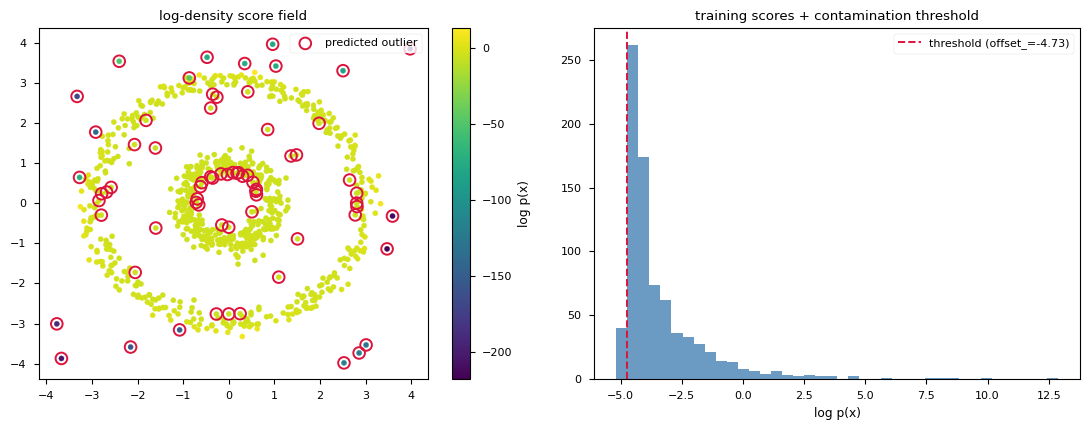

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.4))

sc = ax0.scatter(X_all[:, 0], X_all[:, 1], c=scores, cmap="viridis", s=14)
flagged = labels == -1
ax0.scatter(
    X_all[flagged, 0],
    X_all[flagged, 1],
    facecolors="none",
    edgecolors="crimson",
    s=70,
    linewidths=1.4,
    label="predicted outlier",
)
ax0.set_title("log-density score field")
ax0.legend(loc="upper right", fontsize=8)
fig.colorbar(sc, ax=ax0, label="log p(x)")

ax1.hist(det.train_scores_, bins=40, color="steelblue", alpha=0.8)
ax1.axvline(
    det.offset_,
    color="crimson",
    ls="--",
    label=f"threshold (offset_={det.offset_:.2f})",
)
ax1.set_title("training scores + contamination threshold")
ax1.set_xlabel("log p(x)")
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Recovery of the injected outliers

How many of the 40 injected background points did the detector flag?

In [5]:
recovered = int((labels[len(X) :] == -1).sum())
false_alarms = int((labels[: len(X)] == -1).sum())
print(f"injected outliers flagged: {recovered} / {len(outliers)}")
print(f"inliers mistakenly flagged: {false_alarms} / {len(X)}")

injected outliers flagged: 29 / 40
inliers mistakenly flagged: 40 / 800


## Takeaways

- The score is a **calibrated, global** log-density — unlike
  depth-based (IsolationForest) or local (LOF) scores — so it doubles
  as an off-manifold uncertainty signal for any downstream model.
- The empirical (clipping) marginals are deliberate here: out-of-range
  extremes map to the most extreme rank, which is exactly what anomaly
  *ranking* wants. For likelihood/sampling workflows, prefer the
  tail-extended marginals — see
  [Choosing a marginal](../guides/choosing_a_marginal.md).
- Log-density scores concentrate in high dimensions; above ~30
  features, reduce dimensionality first (e.g. with `RBIGReducer`). The
  [benchmarks](../benchmarks.md) show IsolationForest as the more
  robust default on the higher-dimensional real tables.